# Introduction & Research Questions

**Research Questions**
- In this project, we aim to investigate whether movie budget influences movie revenue using real-world data.
- In this project, we aim to investigate whether popularity, vote count, runtime, and budget influence whether a movie receives a high rating.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Dataset Description

# Data Loading

In [21]:
df = pd.read_csv("tmdb_5000_movies.csv")

df.head()

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


# Data Cleaning

In [22]:
df = df[['budget','revenue','popularity','runtime','vote_average','vote_count']]

df = df.dropna()

df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

df['high_rating'] = (df['vote_average'] >= 7).astype(int)

# Descriptive Statistics

In [35]:
#mean
df.mean()

#median
df.median()

#variance
df.var()

#standard deviation
df.std()

#group statistics example
df.groupby('high_rating')['revenue'].mean()

high_rating
0    1.063456e+08
1    1.689804e+08
Name: revenue, dtype: float64

# Data Visualization

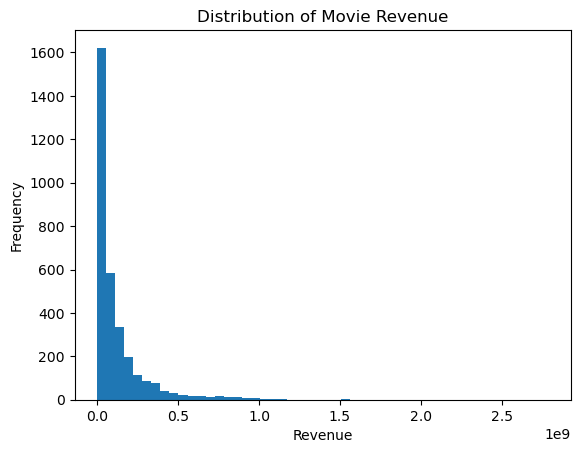

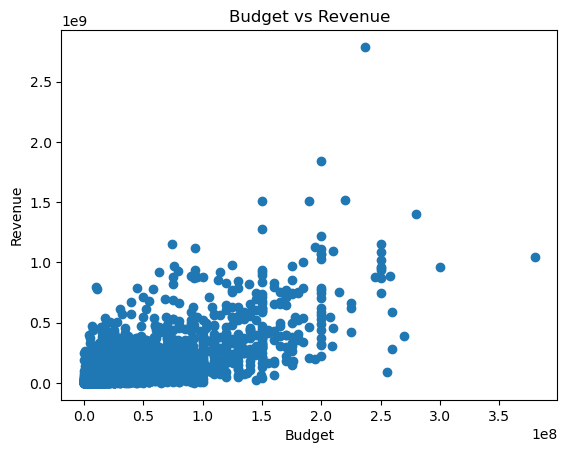

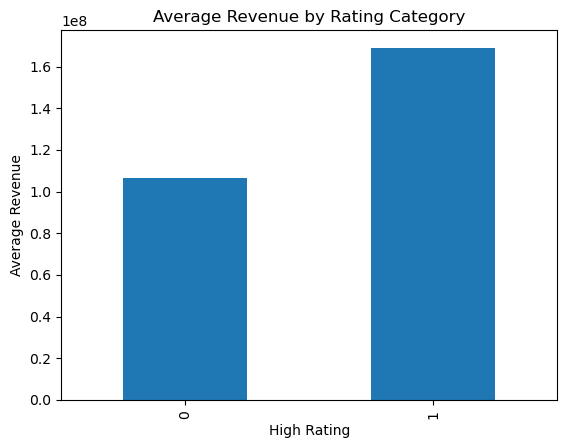

In [24]:
plt.hist(df['revenue'], bins=50)
plt.title("Distribution of Movie Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

plt.scatter(df['budget'], df['revenue'])
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

df.groupby('high_rating')['revenue'].mean().plot(kind='bar')

plt.title("Average Revenue by Rating Category")
plt.xlabel("High Rating")
plt.ylabel("Average Revenue")
plt.show()

# Linear Regression Analysis

In [33]:
budget = df[['budget']]
revenue = df['revenue']

budget_train, budget_test, revenue_train, revenue_test = train_test_split(budget,revenue,test_size=0.2)

revenue_model = LinearRegression()
revenue_model.fit(budget_train,revenue_train)

predictions = revenue_model.predict(budget_test)

print("Coefficient:", revenue_model.coef_)
print("Intercept:", revenue_model.intercept_)

Coefficient: [2.9884845]
Intercept: -596608.8403693587


# Machine Learning Model

In [34]:
rating_features = df[['popularity','vote_count','runtime','budget']]
high_rating = df['high_rating']

features_train, features_test, rating_train, rating_test = train_test_split(rating_features, high_rating, test_size=0.2)

rating_model = LogisticRegression(max_iter=1000)
rating_model.fit(features_train, rating_train)

predictions = rating_model.predict(features_test)

print("Accuracy:", accuracy_score(rating_test,predictions))
print(classification_report(rating_test,predictions))

Accuracy: 0.8204334365325078
              precision    recall  f1-score   support

           0       0.83      0.97      0.89       495
           1       0.77      0.33      0.46       151

    accuracy                           0.82       646
   macro avg       0.80      0.65      0.68       646
weighted avg       0.81      0.82      0.79       646



# Results & Interpretation

# Conclusion